In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/663afdb6-38bb-450c-9f53-a5273c46ea77.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/f95bc1b1-9da1-4970-a3ac-c11155b177e6.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/1dad6ad6-57e3-448c-85d0-0508b05825e9.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/4a14daa4-193d-4bff-a0e1-a634ac673926.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/4b2f4e77-119e-49ed-8e75-0137a3bcde64.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/98800626-538a-4d2b-958f-539c809856d2.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/fc79c489-b358-4368-b965-330615af73d4_00000056.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/07/5742d658-ee7a-41e2-a9ca-a1ae30c6f1cd.jpg
/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs/

In [4]:
# ============================================================
# 0) IMPORTS
# ============================================================
import os, glob, math, gc, json, time
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.mixed_precision import set_global_policy
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input as convnext_preprocess

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, cohen_kappa_score, matthews_corrcoef,
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve

# Mixed precision for speed (beneficial on P100/T4/V100)
set_global_policy("mixed_float16")




In [5]:
# ============================================================
# 1) CONFIGURATION
# ============================================================
class CFG:
    # --- Paths ---
    DATA_DIR    = "/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr"  # your uploaded dataset
    OUTPUT_DIR  = "/kaggle/working/convnext_results"

    # --- Image ---
    IMG_SIZE    = (224, 224)

    # --- Training ---
    BATCH_SIZE       = 32
    EPOCHS_WARMUP    = 5        # Phase 1: frozen backbone
    EPOCHS_FINETUNE  = 20       # Phase 2: unfrozen backbone
    LR_WARMUP        = 1e-3
    LR_FINETUNE      = 5e-4
    LABEL_SMOOTHING  = 0.1
    DROPOUT_RATE     = 0.3

    # --- K-Fold ---
    N_SPLITS     = 5
    TEST_SIZE    = 0.15         # held-out test set (never seen during CV)
    RANDOM_STATE = 42

    # --- Auto ---
    AUTOTUNE = tf.data.AUTOTUNE

os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)


In [6]:
import os
root = "/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr"
for r, dirs, files in os.walk(root):
    level = r.replace(root, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(r)}/  ({len(files)} files)")
    if level >= 2:
        break

kvasir-after-msrcr/  (0 files)
  kvasir_outputs/  (0 files)
    07/  (1000 files)


In [7]:
# ============================================================
# 2) LOAD DATA — Handle numbered folders (00–07)
# ============================================================
from pathlib import Path
from sklearn.utils import shuffle

# The MSRCR dataset has: kvasir_outputs/00, 01, ..., 07
CFG.DATA_DIR = "/kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr"

# Auto-find the folder containing 00, 01, ..., 07
def find_data_root(base_path):
    base = Path(base_path)
    for root, dirs, files in os.walk(str(base)):
        # Look for folder that has numbered subfolders with images
        numbered = [d for d in sorted(dirs) if d.isdigit() or len(d) == 2]
        if len(numbered) >= 8:
            return Path(root)
    return base

data_root = find_data_root(CFG.DATA_DIR)
print(f"[INFO] Data root: {data_root}")

# Get folder names (00, 01, ..., 07)
folder_names = sorted([d.name for d in data_root.iterdir() if d.is_dir()])
print(f"[INFO] Folders found: {folder_names}")

# Map numbered folders to Kvasir v2 class names
# Standard Kvasir v2 order (alphabetical):
KVASIR_CLASSES_SORTED = [
    "dyed-lifted-polyps",       # 00
    "dyed-resection-margins",   # 01
    "esophagitis",              # 02
    "normal-cecum",             # 03
    "normal-pylorus",           # 04
    "normal-z-line",            # 05
    "polyps",                   # 06
    "ulcerative-colitis",       # 07
]

# Verify the mapping by checking a few images from each folder
# (you should manually verify this matches your dataset)
if len(folder_names) == 8:
    class_names = KVASIR_CLASSES_SORTED
    folder_to_class = {folder_names[i]: class_names[i] for i in range(8)}
else:
    # If not exactly 8 folders, just use folder names as class names
    class_names = folder_names
    folder_to_class = {f: f for f in folder_names}

print(f"\n[INFO] Folder → Class mapping:")
for folder, cls in folder_to_class.items():
    print(f"  {folder} → {cls}")

class_to_idx = {name: idx for idx, name in enumerate(class_names)}
N_CLASSES = len(class_names)

# Collect all image paths
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}
image_paths = []
labels = []

for folder_name in folder_names:
    folder_dir = data_root / folder_name
    cls_name = folder_to_class[folder_name]
    cls_idx = class_to_idx[cls_name]
    
    for img_path in sorted(folder_dir.glob("*.*")):
        if img_path.suffix.lower() in IMG_EXTENSIONS:
            image_paths.append(str(img_path))
            labels.append(cls_idx)

image_paths, labels = shuffle(image_paths, labels, random_state=CFG.RANDOM_STATE)
X = np.array(image_paths)
y = np.array(labels)

print(f"\n[INFO] Classes ({N_CLASSES}): {class_names}")
print(f"[INFO] Total images: {len(X)}")
for c in range(N_CLASSES):
    print(f"  {class_names[c]} (folder {folder_names[c]}): {(y == c).sum()}")

[INFO] Data root: /kaggle/input/datasets/debapriyoguha/kvasir-after-msrcr/kvasir_outputs
[INFO] Folders found: ['00', '01', '02', '03', '04', '05', '06', '07']

[INFO] Folder → Class mapping:
  00 → dyed-lifted-polyps
  01 → dyed-resection-margins
  02 → esophagitis
  03 → normal-cecum
  04 → normal-pylorus
  05 → normal-z-line
  06 → polyps
  07 → ulcerative-colitis

[INFO] Classes (8): ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
[INFO] Total images: 8000
  dyed-lifted-polyps (folder 00): 1000
  dyed-resection-margins (folder 01): 1000
  esophagitis (folder 02): 1000
  normal-cecum (folder 03): 1000
  normal-pylorus (folder 04): 1000
  normal-z-line (folder 05): 1000
  polyps (folder 06): 1000
  ulcerative-colitis (folder 07): 1000


In [8]:
# In CFG, change:
CFG.N_SPLITS  = 10
CFG.TEST_SIZE = 0.10    # 10% test

In [9]:
# ============================================================
# 3) TRAIN/TEST SPLIT (80/10/10) → 10-FOLD on TRAIN+VAL
# ============================================================
# Step 1: Hold out 10% as test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=CFG.TEST_SIZE, stratify=y, random_state=CFG.RANDOM_STATE
)

assert set(X_trainval).isdisjoint(set(X_test)), "Data leak!"

# Step 2: 10-Fold on remaining 90%
#   Each fold: train = 9/10 of 90% = 81% ≈ 80% of total
#              val   = 1/10 of 90% =  9% ≈ 10% of total
skf = StratifiedKFold(n_splits=CFG.N_SPLITS, shuffle=True, random_state=CFG.RANDOM_STATE)

folds_data = []
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
    folds_data.append({
        "fold": fold,
        "train_paths":  X_trainval[tr_idx],
        "train_labels": y_trainval[tr_idx],
        "val_paths":    X_trainval[val_idx],
        "val_labels":   y_trainval[val_idx],
    })
    print(f"  Fold {fold}: train={len(tr_idx)}, val={len(val_idx)}")

# Verify split ratio
total = len(X)
print(f"\n[INFO] Split Summary:")
print(f"  Total   : {total}")
print(f"  Train   : {len(folds_data[0]['train_labels'])} ({len(folds_data[0]['train_labels'])/total:.1%})")
print(f"  Val     : {len(folds_data[0]['val_labels'])} ({len(folds_data[0]['val_labels'])/total:.1%})")
print(f"  Test    : {len(X_test)} ({len(X_test)/total:.1%})")

# Save splits for reproducibility
splits_dir = Path(CFG.OUTPUT_DIR) / "splits"
splits_dir.mkdir(exist_ok=True)
pd.DataFrame({"filepath": X_test, "label": y_test}).to_csv(splits_dir / "test.csv", index=False)
for f in folds_data:
    fold = f["fold"]
    pd.DataFrame({"filepath": f["train_paths"], "label": f["train_labels"]}).to_csv(
        splits_dir / f"train_fold{fold}.csv", index=False)
    pd.DataFrame({"filepath": f["val_paths"], "label": f["val_labels"]}).to_csv(
        splits_dir / f"val_fold{fold}.csv", index=False)
print(f"[INFO] Splits saved to: {splits_dir}")

  Fold 0: train=6480, val=720
  Fold 1: train=6480, val=720
  Fold 2: train=6480, val=720
  Fold 3: train=6480, val=720
  Fold 4: train=6480, val=720
  Fold 5: train=6480, val=720
  Fold 6: train=6480, val=720
  Fold 7: train=6480, val=720
  Fold 8: train=6480, val=720
  Fold 9: train=6480, val=720

[INFO] Split Summary:
  Total   : 8000
  Train   : 6480 (81.0%)
  Val     : 720 (9.0%)
  Test    : 800 (10.0%)
[INFO] Splits saved to: /kaggle/working/convnext_results/splits


In [12]:
# ============================================================
# 4) tf.data PIPELINE
# ============================================================
def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, CFG.IMG_SIZE)
    img = tf.cast(img, tf.float32)   # [0, 255]
    return img, label

data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomContrast(0.1),
    layers.RandomZoom(0.05),
], name="augment")

@tf.function
def apply_preprocess(x, y):
    x = convnext_preprocess(x)
    return x, y

def make_dataset(file_paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if training:
        ds = ds.shuffle(len(file_paths), reshuffle_each_iteration=True)
    ds = ds.map(decode_img, num_parallel_calls=CFG.AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augment(x, training=True), y),
                     num_parallel_calls=CFG.AUTOTUNE)
    ds = ds.map(apply_preprocess, num_parallel_calls=CFG.AUTOTUNE)
    ds = ds.batch(CFG.BATCH_SIZE).prefetch(CFG.AUTOTUNE)
    return ds

In [14]:
# ============================================================
# 5) MODEL BUILDER
# ============================================================
def build_model(trainable_backbone=False):
    backbone = ConvNeXtTiny(
        include_top=False,
        weights="imagenet",
        input_shape=(*CFG.IMG_SIZE, 3),
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    inputs = layers.Input(shape=(*CFG.IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG.DROPOUT_RATE)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG.DROPOUT_RATE * 0.5)(x)
    outputs = layers.Dense(N_CLASSES, activation="softmax", dtype="float32")(x)

    return models.Model(inputs, outputs, name="ConvNeXtTiny_Kvasir")


def compile_model(model, lr):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=[metrics.SparseCategoricalAccuracy(name="acc")],
    )


def get_callbacks(fold_id, phase):
    os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)
    ckpt_path = os.path.join(CFG.OUTPUT_DIR, f"best_fold{fold_id}.h5")
    return [
        EarlyStopping(
            monitor="val_acc", patience=6 if phase == "finetune" else 4,
            mode="max", restore_best_weights=True, verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_acc", mode="max", factor=0.5,
            patience=3, min_lr=1e-6, verbose=1,
        ),
        ModelCheckpoint(
            filepath=ckpt_path, monitor="val_acc", mode="max",
            save_best_only=True, verbose=1,
        ),
        CSVLogger(
            os.path.join(CFG.OUTPUT_DIR, f"log_fold{fold_id}.csv"),
            append=(phase == "finetune"),
        ),
    ], ckpt_path


In [16]:
# ============================================================
# 6) TRAIN ONE FOLD (Warmup + Finetune)
# ============================================================
def train_fold(fold_info):
    fold_id = fold_info["fold"]
    print(f"\n{'='*65}")
    print(f"  FOLD {fold_id} / {CFG.N_SPLITS}")
    print(f"{'='*65}")

    train_ds = make_dataset(fold_info["train_paths"], fold_info["train_labels"], training=True)
    val_ds   = make_dataset(fold_info["val_paths"],   fold_info["val_labels"],   training=False)

    # ---- Phase 1: Warmup (backbone frozen) ----
    print("\n--- Phase 1: Warmup (backbone frozen) ---")
    model = build_model(trainable_backbone=False)
    compile_model(model, lr=CFG.LR_WARMUP)

    if fold_id == 0:
        model.summary()

    cbs_warmup, ckpt_path = get_callbacks(fold_id, phase="warmup")

    h1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=CFG.EPOCHS_WARMUP,
        callbacks=cbs_warmup,
        verbose=1,
    )

    # ---- Phase 2: Finetune (backbone unfrozen) ----
    print("\n--- Phase 2: Finetune (backbone unfrozen) ---")
    # Unfreeze backbone
    model.get_layer(index=1).trainable = True
    compile_model(model, lr=CFG.LR_FINETUNE)

    cbs_ft, ckpt_path = get_callbacks(fold_id, phase="finetune")

    h2 = model.fit(
        train_ds, validation_data=val_ds,
        initial_epoch=len(h1.history["loss"]),
        epochs=CFG.EPOCHS_WARMUP + CFG.EPOCHS_FINETUNE,
        callbacks=cbs_ft,
        verbose=1,
    )

    # Merge histories
    history = {}
    for k in h1.history:
        history[k] = h1.history[k] + h2.history[k]

    # Evaluate best weights
    model.load_weights(ckpt_path)
    val_result = model.evaluate(val_ds, verbose=0)

    del train_ds, val_ds
    gc.collect()

    return model, history, ckpt_path, {"val_loss": val_result[0], "val_acc": val_result[1]}

In [17]:
# ---- Speed optimizations ----

# 1) Reduce batch size if you're on P100 (16GB) — mixed precision + ConvNeXt can OOM
#    OR increase it if GPU memory allows (faster per-epoch)
CFG.BATCH_SIZE = 16   # try 16 if 32 is causing slow swapping, or 64 if GPU has room

# 2) Reduce image size (ConvNeXt works fine at 192)
# CFG.IMG_SIZE = (192, 192)   # uncomment if you want even more speed

# 3) Reduce epochs for faster iteration
CFG.EPOCHS_WARMUP   = 5
CFG.EPOCHS_FINETUNE = 25

# 4) Enable XLA compilation (significant speedup on Kaggle GPUs)
tf.config.optimizer.set_jit(True)

# 5) Check what GPU you have
print("GPU:", tf.config.list_physical_devices('GPU'))
!nvidia-smi

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri Mar 27 17:21:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             31W /  250W |     261MiB /  16384MiB |      0%      Default |
|                                         |                        |

In [18]:
# ============================================================
# 7) RUN ALL FOLDS
# ============================================================
fold_models  = []
fold_metrics = []
fold_histories = []

for fold_info in folds_data:
    fold_id = fold_info["fold"]

    model, history, ckpt_path, eval_res = train_fold(fold_info)

    fold_models.append(model)
    fold_metrics.append({"fold": fold_id, **eval_res})
    fold_histories.append(history)

    print(f"\nFOLD {fold_id} → val_loss: {eval_res['val_loss']:.4f} | val_acc: {eval_res['val_acc']:.4f}")

    # Cleanup between folds (keep model reference for ensemble)
    tf.keras.backend.clear_session()
    gc.collect()

    # Reload model from checkpoint for clean state
    fold_models[-1] = build_model(trainable_backbone=True)
    fold_models[-1].load_weights(ckpt_path)



  FOLD 0 / 10

--- Phase 1: Warmup (backbone frozen) ---
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "ConvNeXtTiny_Kvasir"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,023,144 (106.90 MB)

 Trainable params: 200,968 (785.03 KB)

...

405/405 ━━━━━━━━━━━━━━━━━━━━ 62s 152ms/step - acc: 0.7806 - loss: 0.6172 - val_acc: 0.8319 - val_loss: 0.5049 - learning_rate: 0.0010
Epoch 3/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - acc: 0.7953 - loss: 0.5530
Epoch 3: val_acc did not improve from 0.83194
405/405 ━━━━━━━━━━━━━━━━━━━━ 62s 152ms/step - acc: 0.7953 - loss: 0.5530 - val_acc: 0.8292 - val_loss: 0.4889 - learning_rate: 0.0010
Epoch 4/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - acc: 0.7900 - loss: 0.5562
Epoch 4: val_acc did not improve from 0.83194
405/405 ━━━━━━━━━━━━━━━━━━━━ 63s 155ms/step - acc: 0.7900 - loss: 0.5562 - val_acc: 0.8153 - val_loss: 0.4912 - learning_rate: 0.0010
Epoch 5/5
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - acc: 0.8058 - loss: 0.5340
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 5: val_acc did not improve from 0.83194
405/405 ━━━━━━━━━━━━━━━━━━━━ 81s 154ms/step - acc: 0.8058 - loss: 0.5340 - val_acc: 0.7958 - val_loss: 0.5415 - learning_rate: 0.0010
Res

405/405 ━━━━━━━━━━━━━━━━━━━━ 173s 306ms/step - acc: 0.7717 - loss: 0.6474 - val_acc: 0.8056 - val_loss: 0.5308 - learning_rate: 5.0000e-04
Epoch 7/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.8807 - loss: 0.3574
Epoch 7: val_acc improved from 0.80556 to 0.87917, saving model to /kaggle/working/convnext_results/best_fold9.h5


405/405 ━━━━━━━━━━━━━━━━━━━━ 120s 295ms/step - acc: 0.8807 - loss: 0.3573 - val_acc: 0.8792 - val_loss: 0.4786 - learning_rate: 5.0000e-04
Epoch 8/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.9030 - loss: 0.2875
Epoch 8: val_acc did not improve from 0.87917
405/405 ━━━━━━━━━━━━━━━━━━━━ 119s 293ms/step - acc: 0.9030 - loss: 0.2875 - val_acc: 0.8097 - val_loss: 0.5777 - learning_rate: 5.0000e-04
Epoch 9/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - acc: 0.9280 - loss: 0.2314
Epoch 9: val_acc did not improve from 0.87917
405/405 ━━━━━━━━━━━━━━━━━━━━ 118s 291ms/step - acc: 0.9280 - loss: 0.2314 - val_acc: 0.8361 - val_loss: 0.5798 - learning_rate: 5.0000e-04
Epoch 10/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.9344 - loss: 0.2224
Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: val_acc did not improve from 0.87917
405/405 ━━━━━━━━━━━━━━━━━━━━ 118s 292ms/step - acc: 0.9344 - loss: 0.2225 - val_acc: 0.8500 - val_loss: 0.5157 - lea

405/405 ━━━━━━━━━━━━━━━━━━━━ 120s 296ms/step - acc: 0.9558 - loss: 0.1609 - val_acc: 0.9097 - val_loss: 0.3560 - learning_rate: 2.5000e-04
Epoch 12/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - acc: 0.9729 - loss: 0.1246
Epoch 12: val_acc did not improve from 0.90972
405/405 ━━━━━━━━━━━━━━━━━━━━ 119s 293ms/step - acc: 0.9729 - loss: 0.1246 - val_acc: 0.8944 - val_loss: 0.4223 - learning_rate: 2.5000e-04
Epoch 13/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.9723 - loss: 0.1163
Epoch 13: val_acc did not improve from 0.90972
405/405 ━━━━━━━━━━━━━━━━━━━━ 118s 292ms/step - acc: 0.9723 - loss: 0.1164 - val_acc: 0.9097 - val_loss: 0.3317 - learning_rate: 2.5000e-04
Epoch 14/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.9750 - loss: 0.1178
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 14: val_acc did not improve from 0.90972
405/405 ━━━━━━━━━━━━━━━━━━━━ 118s 292ms/step - acc: 0.9750 - loss: 0.1178 - val_acc: 0.9028 - val_loss: 0.4307 -

405/405 ━━━━━━━━━━━━━━━━━━━━ 120s 296ms/step - acc: 0.9905 - loss: 0.0726 - val_acc: 0.9278 - val_loss: 0.3495 - learning_rate: 1.2500e-04
Epoch 16/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.9930 - loss: 0.0618
Epoch 16: val_acc did not improve from 0.92778
405/405 ━━━━━━━━━━━━━━━━━━━━ 118s 292ms/step - acc: 0.9930 - loss: 0.0618 - val_acc: 0.9208 - val_loss: 0.3687 - learning_rate: 1.2500e-04
Epoch 17/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.9943 - loss: 0.0580
Epoch 17: val_acc did not improve from 0.92778
405/405 ━━━━━━━━━━━━━━━━━━━━ 118s 292ms/step - acc: 0.9943 - loss: 0.0580 - val_acc: 0.9167 - val_loss: 0.3713 - learning_rate: 1.2500e-04
Epoch 18/30
405/405 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - acc: 0.9949 - loss: 0.0528
Epoch 18: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 18: val_acc did not improve from 0.92778
405/405 ━━━━━━━━━━━━━━━━━━━━ 118s 292ms/step - acc: 0.9949 - loss: 0.0528 - val_acc: 0.9153 - val_loss: 0.4082 - 

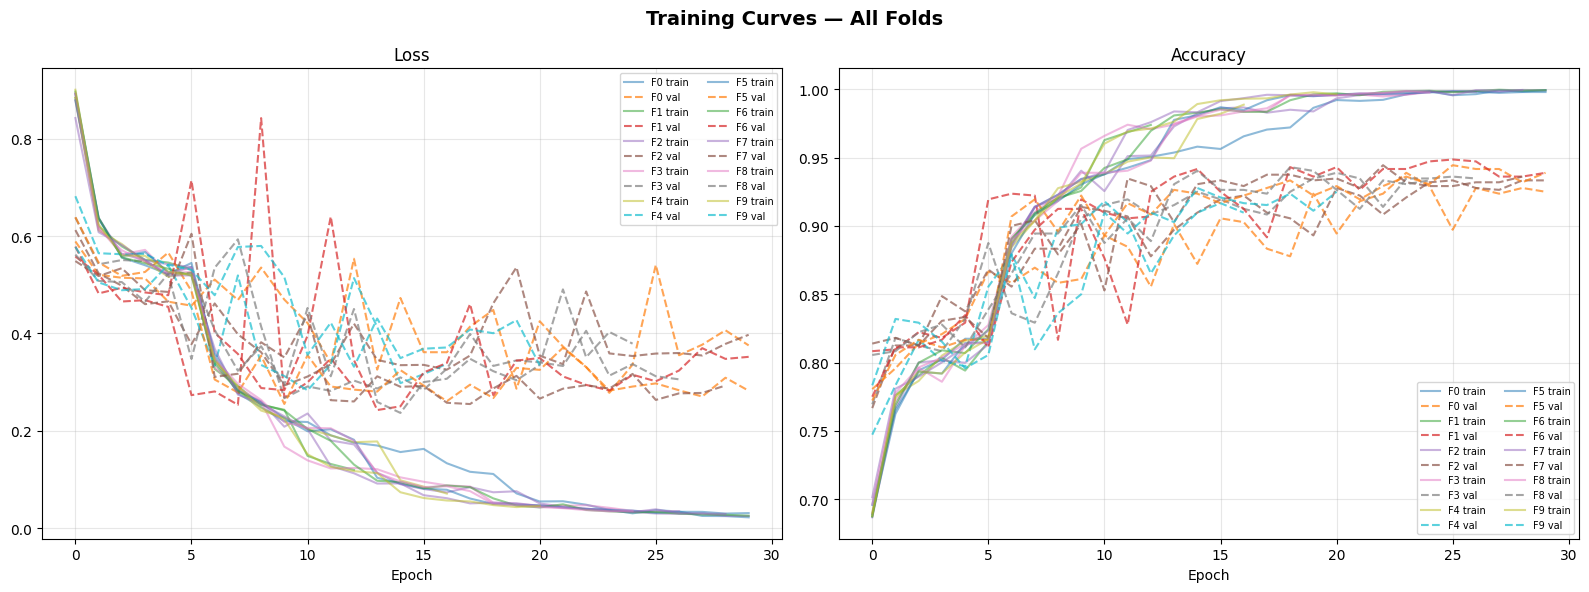

In [26]:
# ============================================================
# 9) TRAINING CURVES (all folds)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for fold_id, h in enumerate(fold_histories):
    axes[0].plot(h["loss"], alpha=0.5, label=f"F{fold_id} train")
    axes[0].plot(h["val_loss"], "--", alpha=0.7, label=f"F{fold_id} val")
    axes[1].plot(h["acc"], alpha=0.5, label=f"F{fold_id} train")
    axes[1].plot(h["val_acc"], "--", alpha=0.7, label=f"F{fold_id} val")

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)
plt.suptitle("Training Curves — All Folds", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "training_curves_all_folds.png"), dpi=200)
plt.show()



In [27]:
# Rebuild from fold_metrics (which was populated in step 7)
val_accs   = [m["val_acc"]  for m in fold_metrics]
val_losses = [m["val_loss"] for m in fold_metrics]

print(f"Fold val accuracies: {val_accs}")

Fold val accuracies: [0.9388889074325562, 0.9236111044883728, 0.9333333373069763, 0.9388889074325562, 0.918055534362793, 0.9444444179534912, 0.9486111402511597, 0.9444444179534912, 0.9430555701255798, 0.9277777671813965]


In [28]:
# ============================================================
# 10) TEST SET EVALUATION — Single Best + Ensemble
# ============================================================
print(f"\n{'='*65}")
print(f"  HELD-OUT TEST SET EVALUATION")
print(f"{'='*65}")

test_ds = make_dataset(X_test, y_test, training=False)

# --- 10a) Ensemble prediction (soft voting) ---
print("\n  Computing ensemble predictions...")
all_probs = []
for i, m in enumerate(fold_models):
    probs = m.predict(test_ds, verbose=0)
    all_probs.append(probs)
    print(f"    Fold {i} predicted")

y_prob_ensemble = np.mean(all_probs, axis=0)
y_pred_ensemble = np.argmax(y_prob_ensemble, axis=1)

# --- 10b) Best single fold ---
best_fold_idx = np.argmax(val_accs)
y_prob_single = all_probs[best_fold_idx]
y_pred_single = np.argmax(y_prob_single, axis=1)

print(f"\n  Best single fold: {best_fold_idx} (val_acc = {val_accs[best_fold_idx]:.4f})")



  HELD-OUT TEST SET EVALUATION

  Computing ensemble predictions...
    Fold 0 predicted
    Fold 1 predicted
    Fold 2 predicted
    Fold 3 predicted
    Fold 4 predicted
    Fold 5 predicted
    Fold 6 predicted
    Fold 7 predicted
    Fold 8 predicted
    Fold 9 predicted

  Best single fold: 6 (val_acc = 0.9486)


In [29]:
# ============================================================
# 11) FULL METRICS FUNCTION
# ============================================================
def full_evaluation(y_true, y_prob, y_pred, set_name="Test"):
    """Compute and display all metrics."""
    y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

    # Core metrics
    acc         = float(np.mean(y_pred == y_true))
    top3        = float(np.mean([y_true[i] in np.argsort(y_prob[i])[-3:] for i in range(len(y_true))]))
    macro_f1    = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    kappa       = cohen_kappa_score(y_true, y_pred)
    mcc         = matthews_corrcoef(y_true, y_pred)

    try:
        macro_auc    = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")
        weighted_auc = roc_auc_score(y_bin, y_prob, average="weighted", multi_class="ovr")
    except:
        macro_auc = weighted_auc = None

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n{'='*65}")
    print(f"  {set_name} — Classification Report")
    print(f"{'='*65}")
    print(report)

    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Top-3 Accuracy : {top3:.4f}")
    print(f"  Macro F1       : {macro_f1:.4f}")
    print(f"  Weighted F1    : {weighted_f1:.4f}")
    print(f"  Cohen's Kappa  : {kappa:.4f}")
    print(f"  MCC            : {mcc:.4f}")
    if macro_auc:
        print(f"  Macro AUC      : {macro_auc:.4f}")
        print(f"  Weighted AUC   : {weighted_auc:.4f}")

    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{set_name} — Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_xticklabels(class_names, rotation=45, ha="right")

    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="YlOrRd",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{set_name} — Confusion Matrix (Normalized)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].set_xticklabels(class_names, rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_confusion_matrix.png"), dpi=200)
    plt.show()

    # --- ROC Curves ---
    plt.figure(figsize=(10, 8))
    per_class_auc = {}
    for c in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
        c_auc = auc(fpr, tpr)
        per_class_auc[class_names[c]] = c_auc
        plt.plot(fpr, tpr, lw=1.5, label=f"{class_names[c]} (AUC={c_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(f"{set_name} — Per-Class ROC Curves")
    plt.legend(loc="lower right", fontsize=8); plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_roc_curves.png"), dpi=200)
    plt.show()

    # --- Precision-Recall Curves ---
    plt.figure(figsize=(10, 8))
    for c in range(N_CLASSES):
        prec, rec, _ = precision_recall_curve(y_bin[:, c], y_prob[:, c])
        ap = average_precision_score(y_bin[:, c], y_prob[:, c])
        plt.plot(rec, prec, lw=1.5, label=f"{class_names[c]} (AP={ap:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{set_name} — Precision-Recall Curves")
    plt.legend(loc="lower left", fontsize=8); plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_pr_curves.png"), dpi=200)
    plt.show()

    # --- Per-class accuracy bar chart ---
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    colors = plt.cm.Set2(np.linspace(0, 1, N_CLASSES))
    plt.figure(figsize=(12, 5))
    bars = plt.bar(class_names, per_class_acc, color=colors, edgecolor="black", linewidth=0.5)
    for bar, v in zip(bars, per_class_acc):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{v:.1%}", ha="center", fontsize=9)
    plt.ylim(0, 1.15); plt.ylabel("Accuracy")
    plt.title(f"{set_name} — Per-Class Accuracy")
    plt.xticks(rotation=45, ha="right"); plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_per_class_acc.png"), dpi=200)
    plt.show()

    # --- Calibration / ECE ---
    conf = np.max(y_prob, axis=1)
    correct = (y_pred == y_true).astype(int)
    bins = np.linspace(0, 1, 11)
    bin_ids = np.digitize(conf, bins) - 1
    ECE = 0.0
    N = len(conf)
    bin_acc_list, bin_conf_list = [], []
    for b in range(len(bins) - 1):
        idx = bin_ids == b
        if idx.sum() > 0:
            acc_b = correct[idx].mean()
            conf_b = conf[idx].mean()
            ECE += (idx.sum() / N) * abs(acc_b - conf_b)
            bin_acc_list.append(acc_b)
            bin_conf_list.append(conf_b)
        else:
            bin_acc_list.append(np.nan)
            bin_conf_list.append(np.nan)

    centers = 0.5 * (bins[:-1] + bins[1:])
    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect")
    plt.scatter(centers, bin_acc_list, s=50, zorder=5, label="Observed")
    plt.xlabel("Confidence"); plt.ylabel("Accuracy")
    plt.title(f"{set_name} — Reliability Diagram (ECE={ECE:.4f})")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(CFG.OUTPUT_DIR, f"{set_name.lower()}_calibration.png"), dpi=200)
    plt.show()
    print(f"  ECE            : {ECE:.4f}")

    return {
        "accuracy": acc, "top3_accuracy": top3,
        "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1),
        "cohen_kappa": float(kappa), "mcc": float(mcc),
        "macro_auc": float(macro_auc) if macro_auc else None,
        "weighted_auc": float(weighted_auc) if weighted_auc else None,
        "ece": float(ECE),
        "per_class_auc": {k: float(v) for k, v in per_class_auc.items()},
    }




  TEST — Best Single Fold (6)

  Test_SingleBest — Classification Report
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9314    0.9500    0.9406       100
dyed-resection-margins     0.9495    0.9400    0.9447       100
           esophagitis     0.8776    0.8600    0.8687       100
          normal-cecum     0.9897    0.9600    0.9746       100
        normal-pylorus     1.0000    1.0000    1.0000       100
         normal-z-line     0.8627    0.8800    0.8713       100
                polyps     0.9592    0.9400    0.9495       100
    ulcerative-colitis     0.9423    0.9800    0.9608       100

              accuracy                         0.9387       800
             macro avg     0.9390    0.9387    0.9388       800
          weighted avg     0.9390    0.9387    0.9388       800

  Accuracy       : 0.9387
  Top-3 Accuracy : 1.0000
  Macro F1       : 0.9388
  Weighted F1    : 0.9388
  Cohen's Kappa  : 0.9300
  MCC            : 0.9300

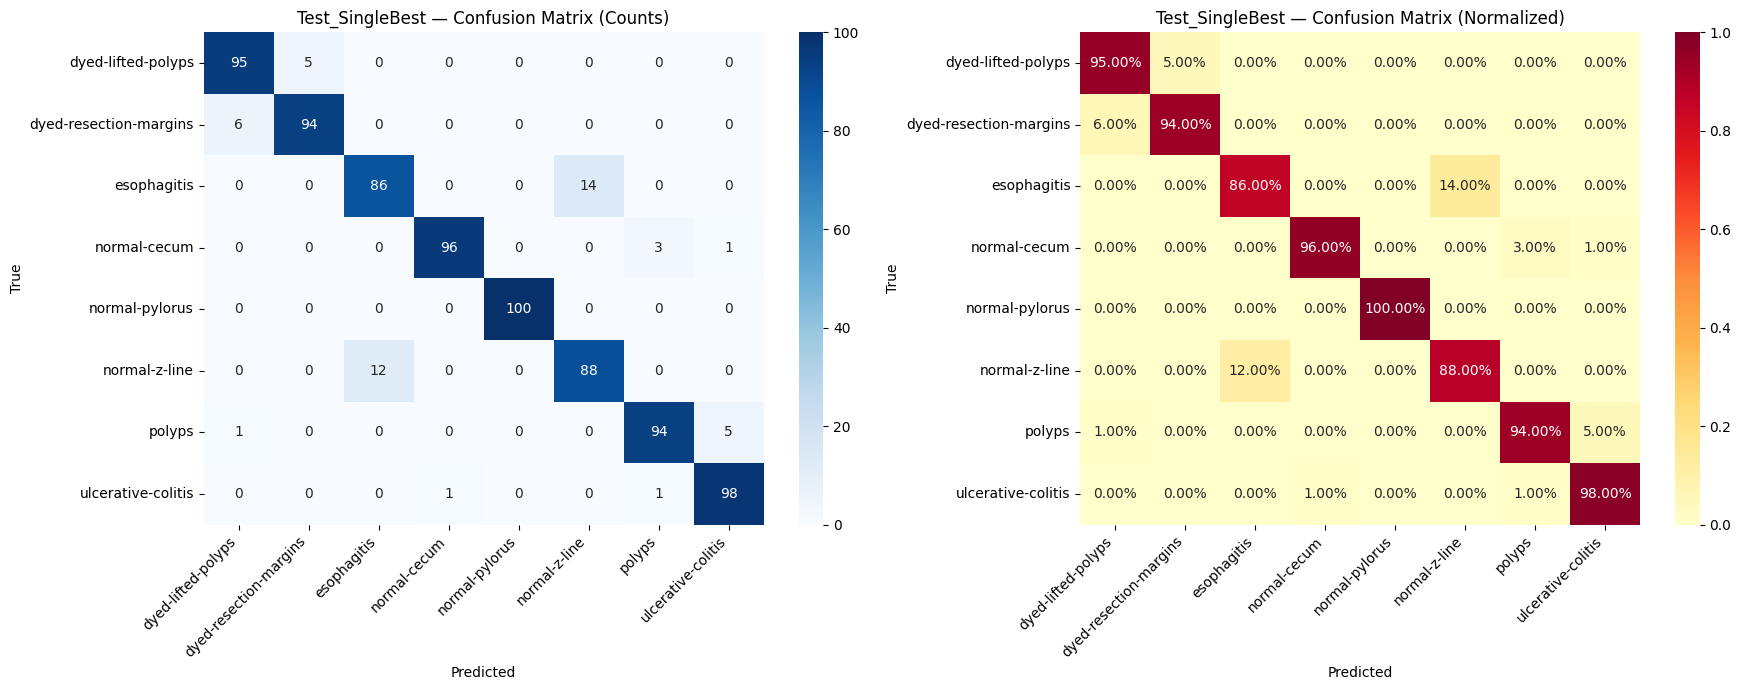

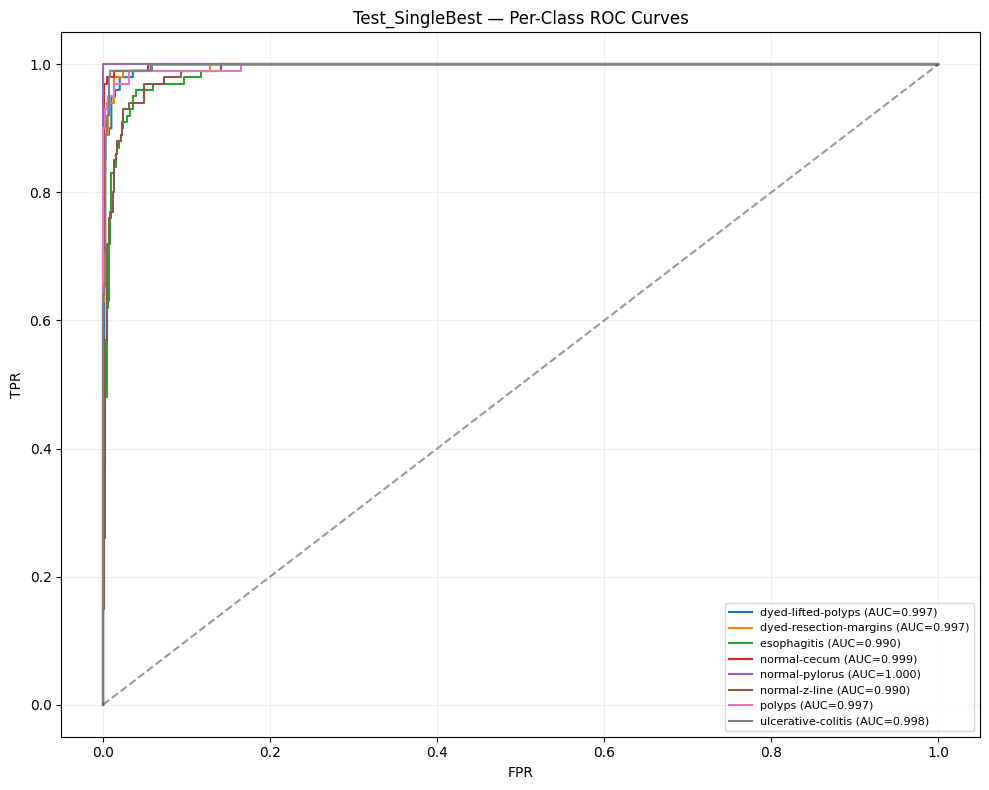

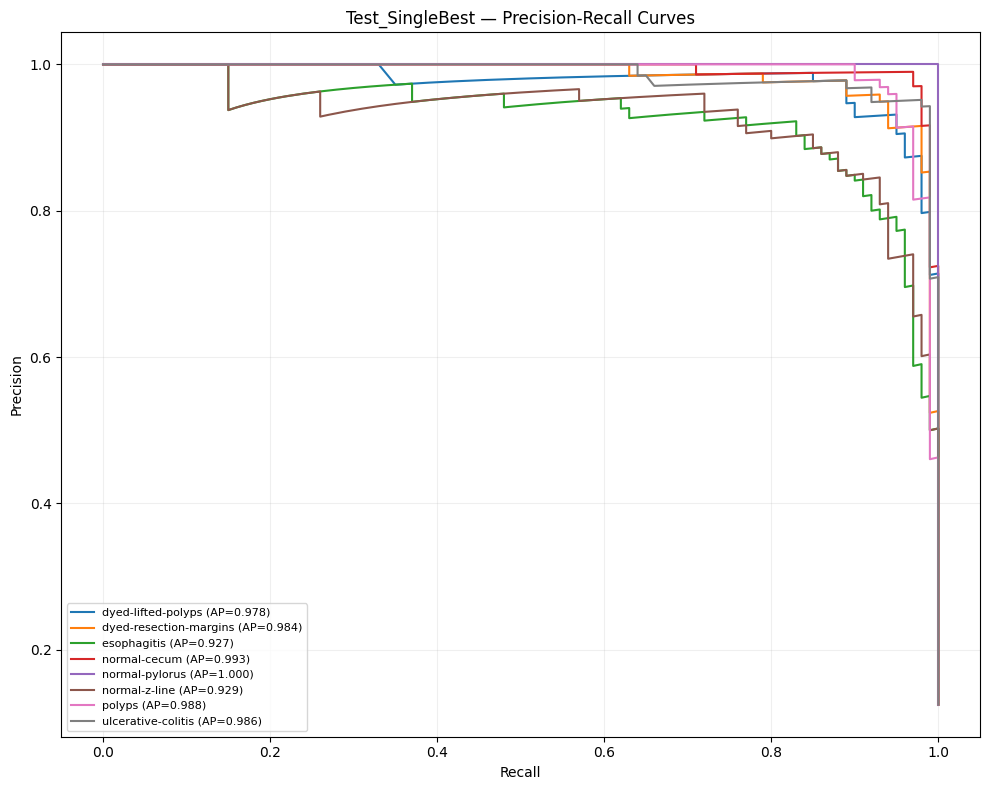

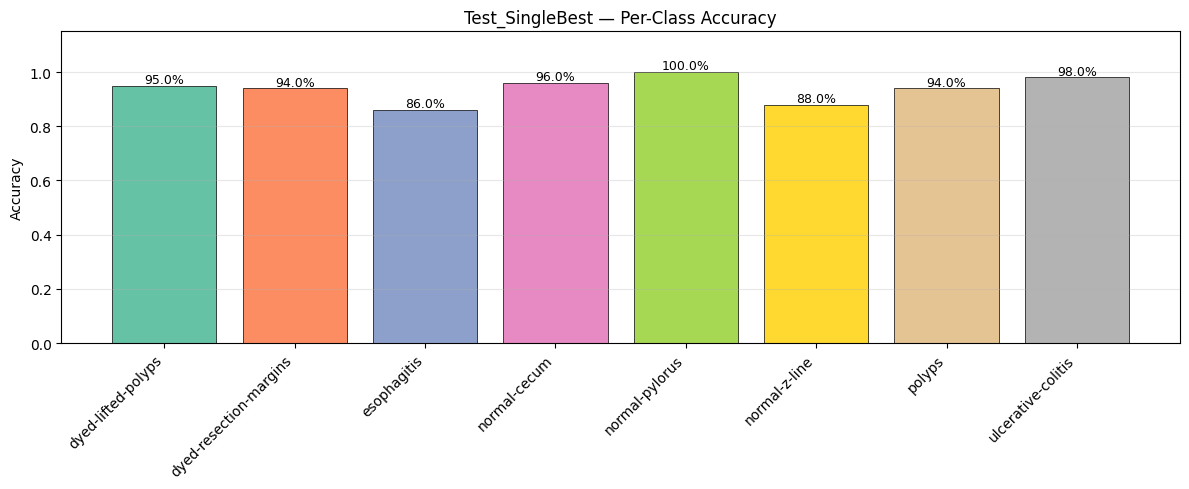

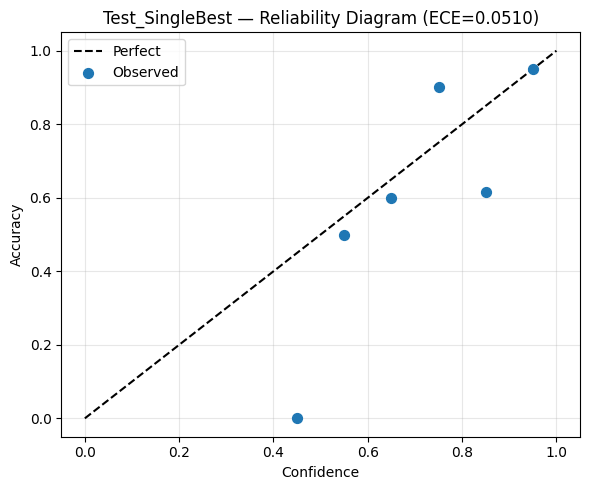

  ECE            : 0.0510

  TEST — Ensemble (10 folds, soft voting)

  Test_Ensemble — Classification Report
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.8981    0.9700    0.9327       100
dyed-resection-margins     0.9670    0.8800    0.9215       100
           esophagitis     0.9062    0.8700    0.8878       100
          normal-cecum     0.9800    0.9800    0.9800       100
        normal-pylorus     1.0000    1.0000    1.0000       100
         normal-z-line     0.8750    0.9100    0.8922       100
                polyps     1.0000    0.9800    0.9899       100
    ulcerative-colitis     0.9612    0.9900    0.9754       100

              accuracy                         0.9475       800
             macro avg     0.9484    0.9475    0.9474       800
          weighted avg     0.9484    0.9475    0.9474       800

  Accuracy       : 0.9475
  Top-3 Accuracy : 1.0000
  Macro F1       : 0.9474
  Weighted F1    : 0.9474
  Cohen's Kappa

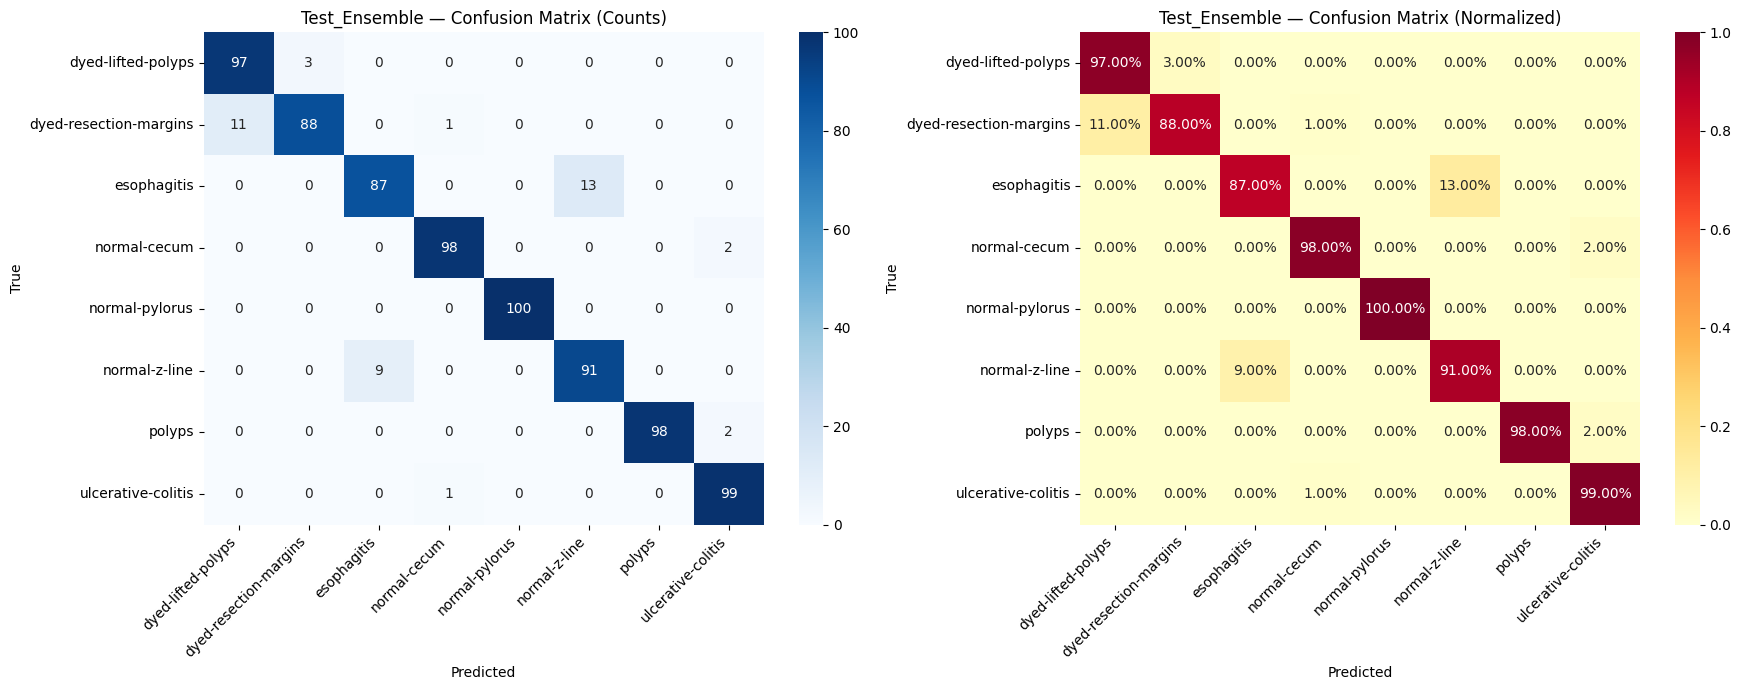

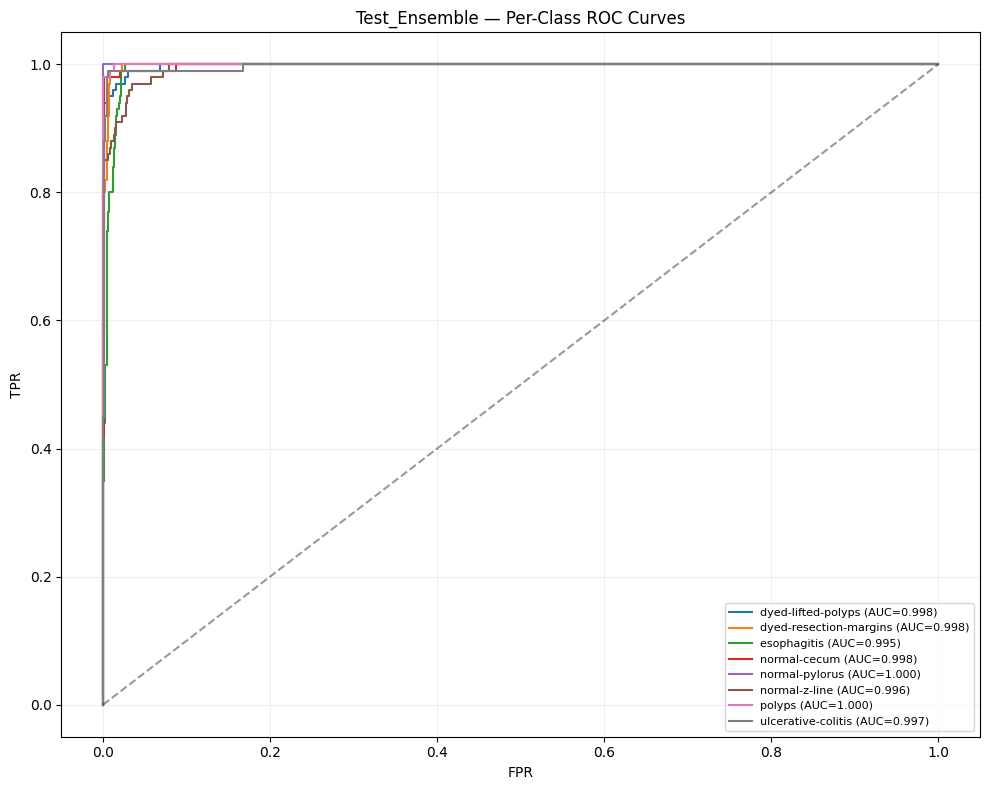

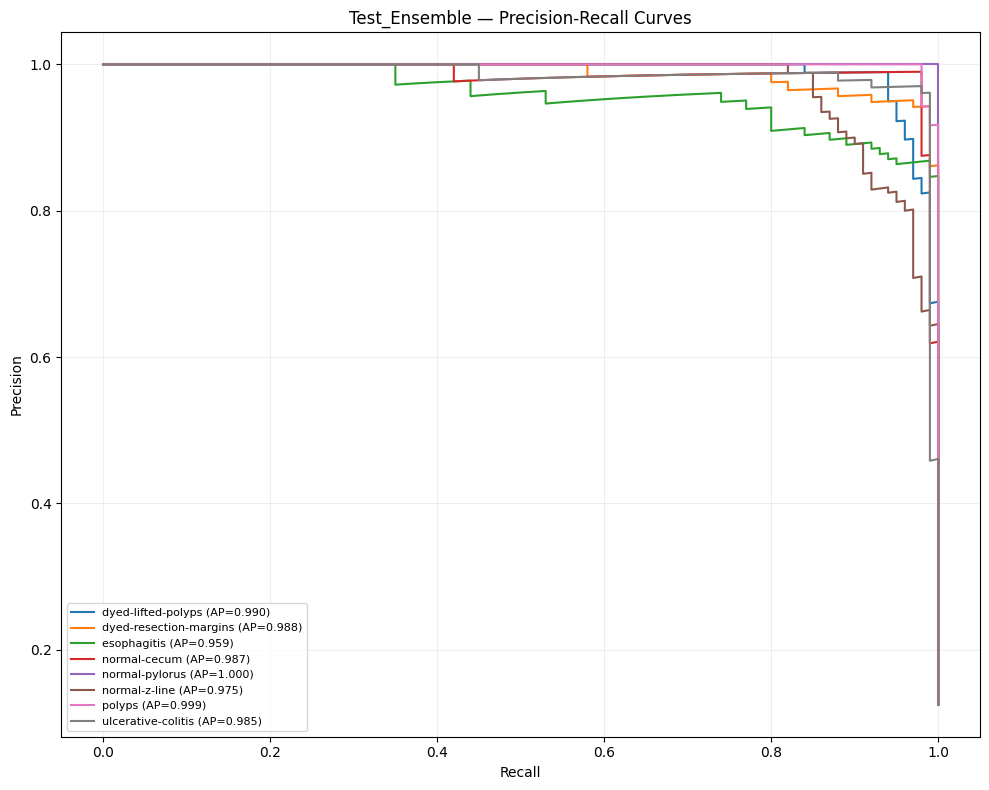

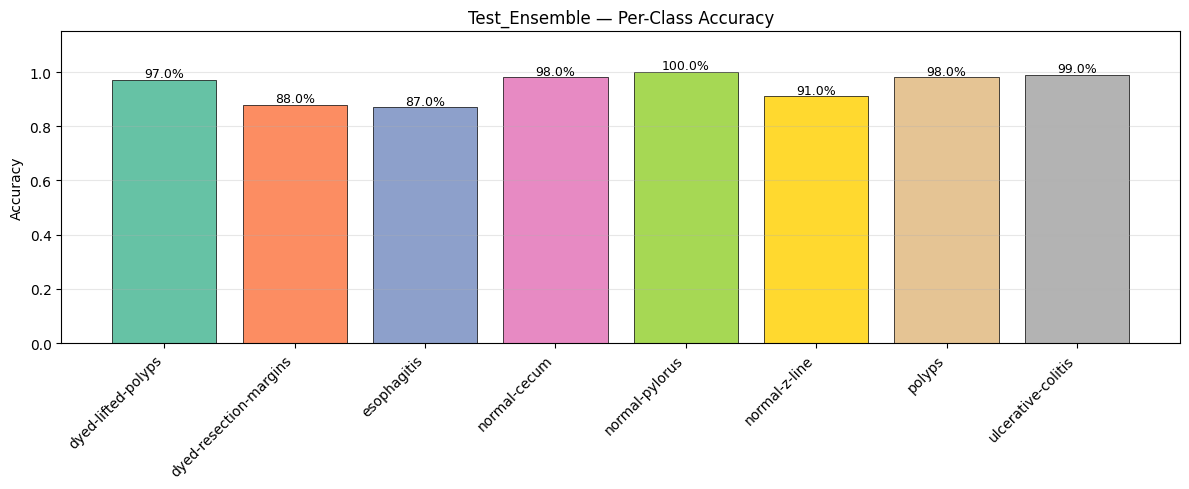

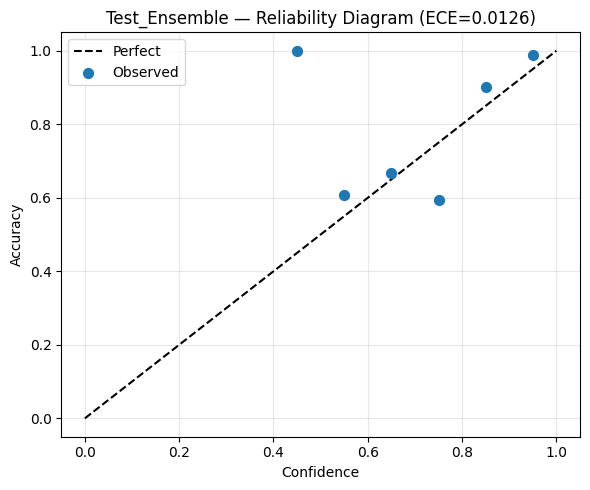

  ECE            : 0.0126


In [30]:
# ============================================================
# 12) RUN EVALUATION
# ============================================================

# Single best fold
print(f"\n{'='*65}")
print(f"  TEST — Best Single Fold ({best_fold_idx})")
print(f"{'='*65}")
single_results = full_evaluation(y_test, y_prob_single, y_pred_single, set_name="Test_SingleBest")

# Ensemble
print(f"\n{'='*65}")
print(f"  TEST — Ensemble ({len(fold_models)} folds, soft voting)")
print(f"{'='*65}")
ensemble_results = full_evaluation(y_test, y_prob_ensemble, y_pred_ensemble, set_name="Test_Ensemble")


In [31]:
# ============================================================
# 13) COMPARISON TABLE
# ============================================================
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Top-3 Accuracy", "Macro F1", "Weighted F1",
               "Cohen's Kappa", "MCC", "Macro AUC", "Weighted AUC", "ECE"],
    "Single Best": [single_results[k] for k in
        ["accuracy", "top3_accuracy", "macro_f1", "weighted_f1",
         "cohen_kappa", "mcc", "macro_auc", "weighted_auc", "ece"]],
    "Ensemble": [ensemble_results[k] for k in
        ["accuracy", "top3_accuracy", "macro_f1", "weighted_f1",
         "cohen_kappa", "mcc", "macro_auc", "weighted_auc", "ece"]],
})

print(f"\n{'='*65}")
print(f"  Single Best vs Ensemble")
print(f"{'='*65}")
print(comparison.to_string(index=False))
comparison.to_csv(os.path.join(CFG.OUTPUT_DIR, "comparison.csv"), index=False)



  Single Best vs Ensemble
        Metric  Single Best  Ensemble
      Accuracy     0.938750  0.947500
Top-3 Accuracy     1.000000  1.000000
      Macro F1     0.938774  0.947417
   Weighted F1     0.938774  0.947417
 Cohen's Kappa     0.930000  0.940000
           MCC     0.930035  0.940160
     Macro AUC     0.996079  0.997802
  Weighted AUC     0.996079  0.997802
           ECE     0.051002  0.012621


In [32]:
# ============================================================
# 14) SAVE EXPERIMENT SUMMARY
# ============================================================
summary = {
    "model": "ConvNeXt-Tiny",
    "preprocessing": "CLAHE + Gaussian + Bilateral",
    "dataset": "Kvasir v2",
    "img_size": list(CFG.IMG_SIZE),
    "batch_size": CFG.BATCH_SIZE,
    "epochs_warmup": CFG.EPOCHS_WARMUP,
    "epochs_finetune": CFG.EPOCHS_FINETUNE,
    "lr_warmup": CFG.LR_WARMUP,
    "lr_finetune": CFG.LR_FINETUNE,
    "n_folds": CFG.N_SPLITS,
    "test_size": CFG.TEST_SIZE,
    "fold_val_accuracies": val_accs,
    "mean_val_acc": float(np.mean(val_accs)),
    "std_val_acc": float(np.std(val_accs)),
    "best_single_fold": int(best_fold_idx),
    "test_single_best": {k: v for k, v in single_results.items() if k != "per_class_auc"},
    "test_ensemble": {k: v for k, v in ensemble_results.items() if k != "per_class_auc"},
}

with open(os.path.join(CFG.OUTPUT_DIR, "experiment_summary.json"), "w") as f:
    json.dump(summary, f, indent=2, default=str)

with open(os.path.join(CFG.OUTPUT_DIR, "classification_report_ensemble.txt"), "w") as f:
    f.write(classification_report(y_test, y_pred_ensemble, target_names=class_names, digits=4))


print(f"\n{'='*65}")
print(f"  ALL DONE — Results saved to '{CFG.OUTPUT_DIR}/'")
print(f"{'='*65}")
print(f"\n  Files:")
print(f"    splits/                         — reproducible train/val/test CSVs")
print(f"    best_fold*.h5                   — model weights per fold")
print(f"    log_fold*.csv                   — training logs per fold")
print(f"    training_curves_all_folds.png   — loss/acc curves")
print(f"    test_*_confusion_matrix.png     — confusion matrices")
print(f"    test_*_roc_curves.png           — ROC curves")
print(f"    test_*_pr_curves.png            — precision-recall curves")
print(f"    test_*_per_class_acc.png        — per-class accuracy bars")
print(f"    test_*_calibration.png          — reliability diagrams")
print(f"    comparison.csv                  — single vs ensemble table")
print(f"    experiment_summary.json         — complete experiment config + results")
print(f"\n  Key Results:")
print(f"    CV Mean Acc      : {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"    Test Acc (single): {single_results['accuracy']:.4f}")
print(f"    Test Acc (ens.)  : {ensemble_results['accuracy']:.4f}")
print(f"    Test Macro AUC   : {ensemble_results.get('macro_auc', 'N/A')}")


  ALL DONE — Results saved to '/kaggle/working/convnext_results/'

  Files:
    splits/                         — reproducible train/val/test CSVs
    best_fold*.h5                   — model weights per fold
    log_fold*.csv                   — training logs per fold
    training_curves_all_folds.png   — loss/acc curves
    test_*_confusion_matrix.png     — confusion matrices
    test_*_roc_curves.png           — ROC curves
    test_*_pr_curves.png            — precision-recall curves
    test_*_per_class_acc.png        — per-class accuracy bars
    test_*_calibration.png          — reliability diagrams
    comparison.csv                  — single vs ensemble table
    experiment_summary.json         — complete experiment config + results

  Key Results:
    CV Mean Acc      : 0.9361 ± 0.0096
    Test Acc (single): 0.9387
    Test Acc (ens.)  : 0.9475
    Test Macro AUC   : 0.9978017857142857
